In [8]:
from typing import TypedDict, Literal
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END


In [9]:
class PortfolioState(TypedDict):
    amount_in_usd: float
    amount_total_in_usd: float
    target_currency: Literal['inr', 'euro']
    amount_total: float


In [10]:
def Calculate_total_inr(state: PortfolioState) -> PortfolioState:
    state['amount_total'] = state['amount_total_in_usd'] * 92.0
    return state

def Calculate_total_usd(state: PortfolioState) -> PortfolioState:
    state['amount_total_in_usd'] = state['amount_in_usd']* 1.08
    return state

def Select_currency(state: PortfolioState) -> str:
    return state['target_currency']

def Calculate_total_eros(state: PortfolioState) -> PortfolioState:
    state['amount_total'] = state['amount_total_in_usd']* 0.95
    return state

In [11]:
graph_builder = StateGraph(PortfolioState)

graph_builder.add_node("Calculate_total_usd", Calculate_total_usd)
graph_builder.add_node("Calculate_total_inr", Calculate_total_inr)
graph_builder.add_node("Calculate_total_eros", Calculate_total_eros)

graph_builder.add_edge(START, "Calculate_total_usd")
graph_builder.add_conditional_edges("Calculate_total_usd", Select_currency, {
    'inr': "Calculate_total_inr",
    'euro': "Calculate_total_eros"  
})
graph_builder.add_edge("Calculate_total_inr", END)
graph_builder.add_edge("Calculate_total_eros", END)



graph = graph_builder.compile()

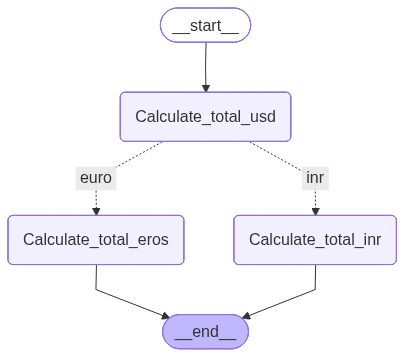

In [12]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
graph.invoke({"amount_in_usd": 2000.0, "target_currency": "inr"})

{'amount_in_usd': 2000.0,
 'amount_total_in_usd': 2160.0,
 'target_currency': 'inr',
 'amount_total': 198720.0}

In [14]:
graph.invoke({"amount_in_usd": 2000.0, "target_currency": "euro"})

{'amount_in_usd': 2000.0,
 'amount_total_in_usd': 2160.0,
 'target_currency': 'euro',
 'amount_total': 2052.0}